In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# random number generator for reproducable results
rng = np.random.default_rng(2026)

In [ ]:
%pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
spambase = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

In [ ]:
X.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.031869,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.285735,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,10.000000,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000


In [ ]:
y.describe()

,Class
count,4601.000000
mean,0.394045
std,0.488698
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
# clean data
print("Null values in each column:\n", X.isnull().sum(), "\n")

X_clean = X.dropna()
num_samples, num_features = X.shape
print("Number of Samples:", num_samples)
print("Number of Features:", num_features, '\n')

# shuffle dataset, using same number to always have same split
random_state=rng.integers(0, 1000000)
X_shuffled = X_clean.sample(frac=1, random_state=random_state)
y_shuffled = y.sample(frac=1, random_state=random_state)
# split index for 5/95 train-test split
split_idx = int(len(X_shuffled) * 0.05)
# split the shuffled data into training and test sets
X_train = X_shuffled.iloc[:split_idx]
y_train = y_shuffled.iloc[:split_idx]
X_test = X_shuffled.iloc[split_idx:]
y_test = y_shuffled.iloc[split_idx:]

# convert to NumPy arrays for from-scratch implementation
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

X_test = X_test.to_numpy()
y_test = y_test.to_numpy()

# ensure labels are 1D
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

Null values in each column:
 word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_t

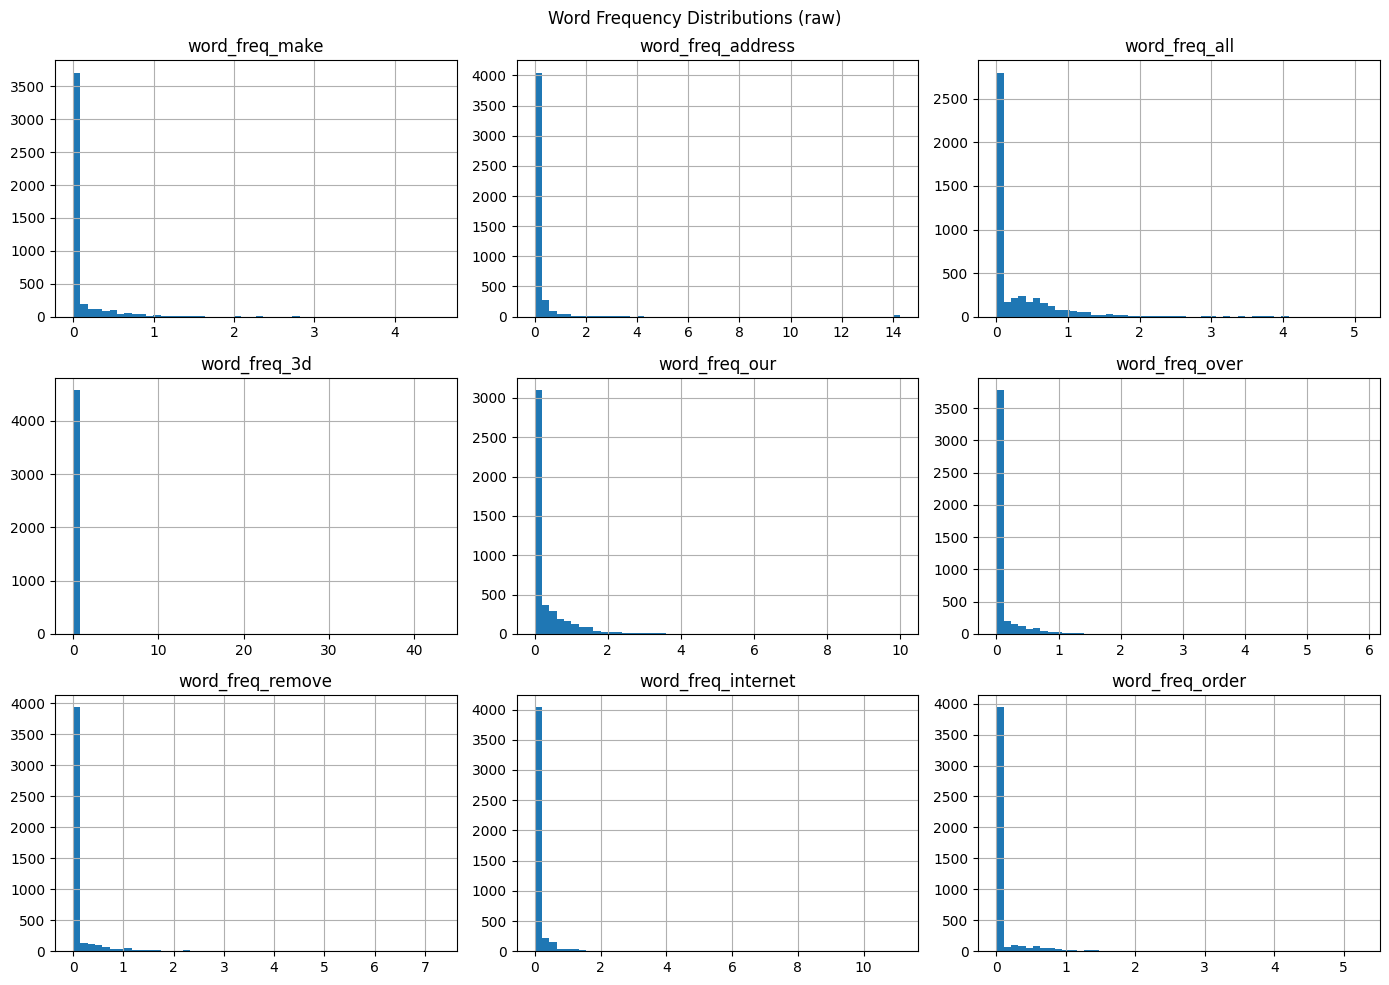

In [ ]:
# make plots to explore word frequency features
word_cols = [c for c in X.columns if c.startswith('word_freq')][:9]
X[word_cols].hist(bins=50, figsize=(14, 10))
plt.suptitle("Word Frequency Distributions (raw)")
plt.tight_layout()
plt.show()

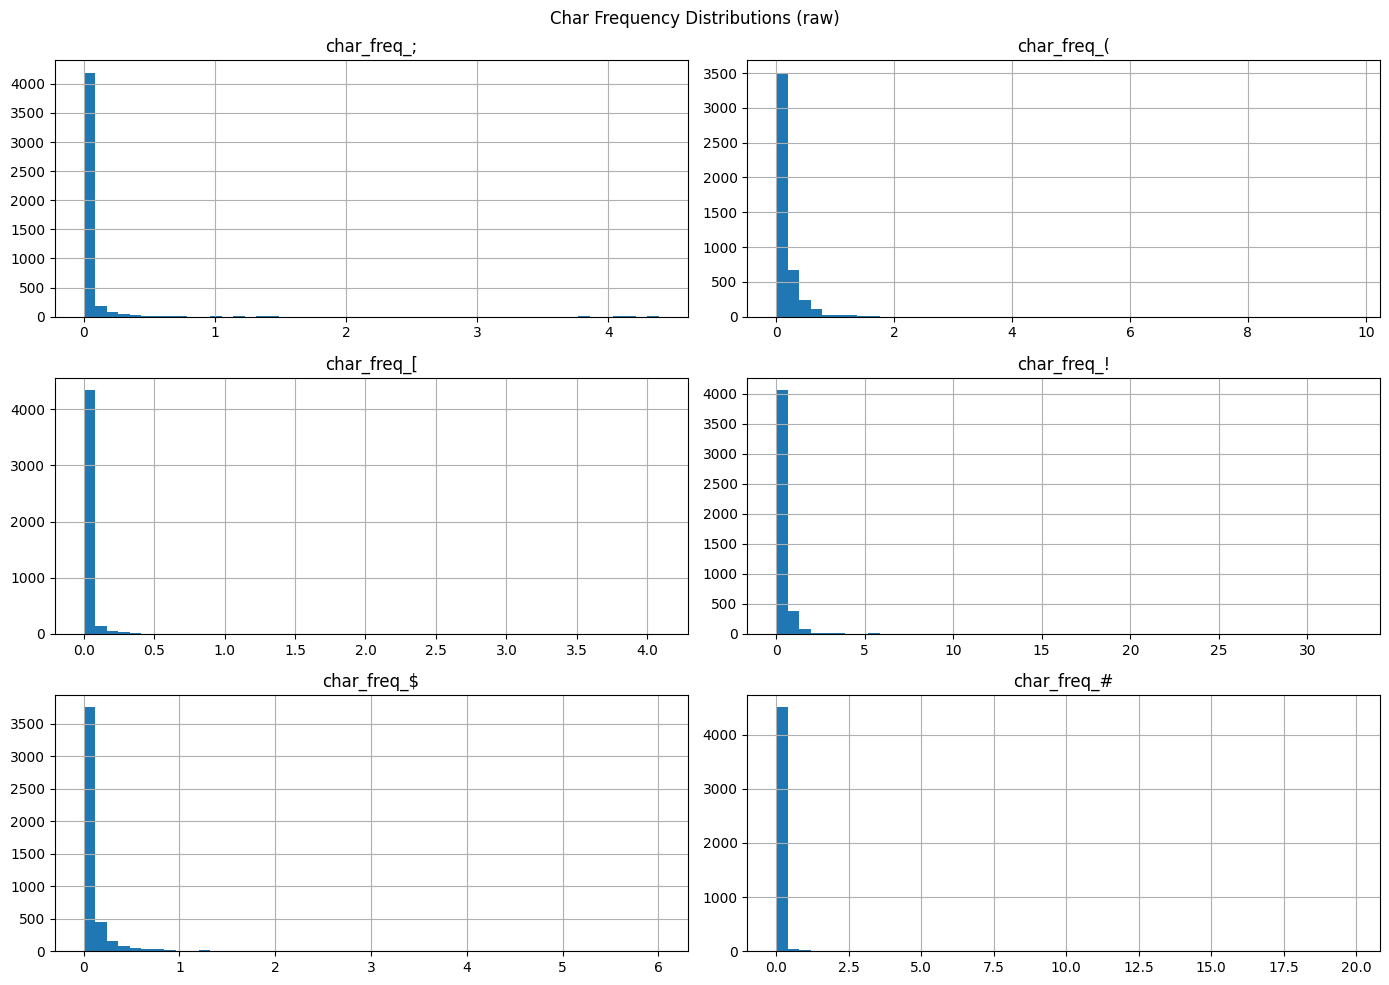

In [ ]:
# make plots to explore character frequency features
char_cols = [c for c in X.columns if c.startswith('char_freq')][:9]
X[char_cols].hist(bins=50, figsize=(14, 10))
plt.suptitle("Char Frequency Distributions (raw)")
plt.tight_layout()
plt.show()

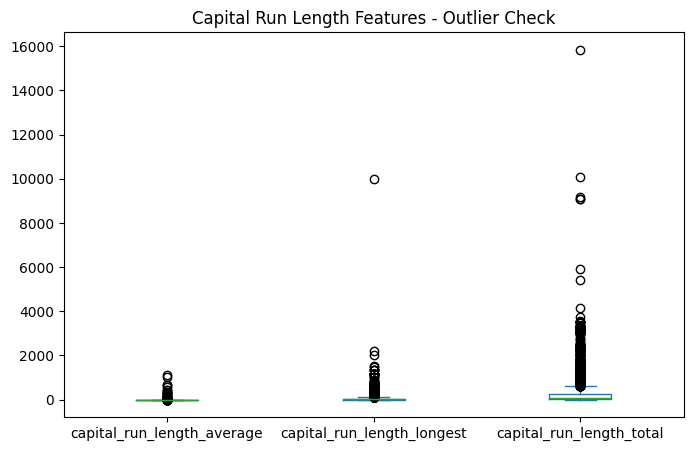

In [ ]:
# plots to explore capital runs features
cap_cols = ['capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total']
X[cap_cols].plot(kind='box', figsize=(8, 5))
plt.title("Capital Run Length Features - Outlier Check")
plt.show()

In [ ]:
# standardize: make sure to compute parameters only from test set
X.describe().loc[['mean', 'std', 'min', 'max']].T.sort_values('max', ascending=False)

# using standard normalization
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_unstandardized = X_train.copy()
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

## **Utilities**

In [ ]:
# Utilities

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy_loss(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

def forward(X, w, b):
    z = X @ w + b
    return sigmoid(z)

def compute_gradients(X, y, w, b, lam):
    """
    X: (B, d)
    y: (B,)
    """
    B = X.shape[0]

    y_hat = forward(X, w, b)
    error = y_hat - y

    grad_w = (X.T @ error) / B
    grad_b = np.mean(error)

    # L2 regularization (bias excluded)
    grad_w += 2 * lam * w

    return grad_w, grad_b

def compute_accuracy(y_true, y_pred):
    y_class = (y_pred >= 0.5).astype(int)
    return np.mean(y_class == y_true)

In [ ]:
def train_logistic_regression(
    X, y,
    lr=1e-2,
    batch_size=16,
    epochs=100,
    lam=0.0
):
    n_samples, n_features = X.shape

    # Initialize parameters
    w = rng.normal(0, 0.01, size=n_features)
    b = 0.0

    losses = []
    accuracies = []

    for epoch in range(epochs):
        # Shuffle every epoch
        indices = rng.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            grad_w, grad_b = compute_gradients(
                X_batch, y_batch, w, b, lam
            )

            w -= lr * grad_w
            b -= lr * grad_b

        # Track training loss
        y_pred = forward(X, w, b)
        loss = cross_entropy_loss(y, y_pred)
        losses.append(loss)

        acc = compute_accuracy(y, y_pred)
        accuracies.append(acc)

    return w, b, losses, accuracies

## **Running Experiments**

In [ ]:
batch_sizes = [1, 16, 64]
learning_rates = [1, 1e-1, 1e-2, 1e-3, 1e-4]
epochs = 100

lambda_no_reg = 0.0
lambda_l2 = 1e-3

In [ ]:
results = {}

for B in batch_sizes:
    for lr in learning_rates:
        config_name = f"B={B}, lr={lr}"

        print(f"Running {config_name} (no regularization)")
        _, _, losses_nr, acc_nr = train_logistic_regression(
            X_train, y_train,
            lr=lr,
            batch_size=B,
            epochs=epochs,
            lam=lambda_no_reg
        )

        print(f"Running {config_name} (L2 regularization)")
        _, _, losses_l2, acc_l2 = train_logistic_regression(
            X_train, y_train,
            lr=lr,
            batch_size=B,
            epochs=epochs,
            lam=lambda_l2
        )

        results[(B, lr)] = {
            "no_reg": {
                "loss": losses_nr,
                "acc": acc_nr
            },
            "l2": {
                "loss": losses_l2,
                "acc": acc_l2
            }
        }

Running B=1, lr=1 (no regularization)
Running B=1, lr=1 (L2 regularization)
Running B=1, lr=0.1 (no regularization)
Running B=1, lr=0.1 (L2 regularization)
Running B=1, lr=0.01 (no regularization)
Running B=1, lr=0.01 (L2 regularization)
Running B=1, lr=0.001 (no regularization)
Running B=1, lr=0.001 (L2 regularization)
Running B=1, lr=0.0001 (no regularization)
Running B=1, lr=0.0001 (L2 regularization)
Running B=16, lr=1 (no regularization)
Running B=16, lr=1 (L2 regularization)
Running B=16, lr=0.1 (no regularization)
Running B=16, lr=0.1 (L2 regularization)
Running B=16, lr=0.01 (no regularization)
Running B=16, lr=0.01 (L2 regularization)
Running B=16, lr=0.001 (no regularization)
Running B=16, lr=0.001 (L2 regularization)
Running B=16, lr=0.0001 (no regularization)
Running B=16, lr=0.0001 (L2 regularization)
Running B=64, lr=1 (no regularization)
Running B=64, lr=1 (L2 regularization)
Running B=64, lr=0.1 (no regularization)
Running B=64, lr=0.1 (L2 regularization)
Running B=64, 

In [ ]:
final_loss_no_reg = np.zeros((len(batch_sizes), len(learning_rates)))
final_loss_l2 = np.zeros_like(final_loss_no_reg)

for i, B in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        final_loss_no_reg[i, j] = results[(B, lr)]["no_reg"]["loss"][-1]
        final_loss_l2[i, j] = results[(B, lr)]["l2"]["loss"][-1]

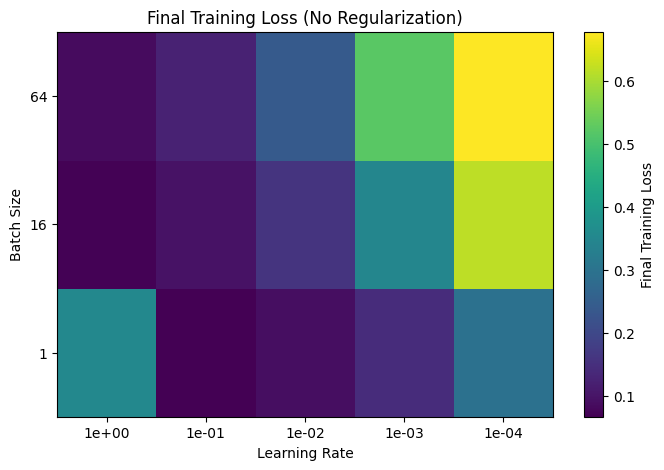

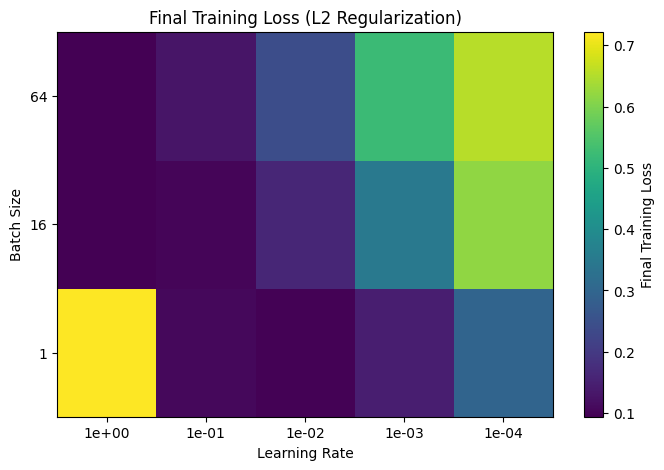

In [ ]:
plt.figure(figsize=(8, 5))
plt.imshow(final_loss_no_reg, aspect="auto", origin="lower")
plt.colorbar(label="Final Training Loss")
plt.xticks(range(len(learning_rates)),
           [f"{lr:.0e}" for lr in learning_rates])
plt.yticks(range(len(batch_sizes)), batch_sizes)
plt.xlabel("Learning Rate")
plt.ylabel("Batch Size")
plt.title("Final Training Loss (No Regularization)")
plt.show()


plt.figure(figsize=(8, 5))
plt.imshow(final_loss_l2, aspect="auto", origin="lower")
plt.colorbar(label="Final Training Loss")
plt.xticks(range(len(learning_rates)),
           [f"{lr:.0e}" for lr in learning_rates])
plt.yticks(range(len(batch_sizes)), batch_sizes)
plt.xlabel("Learning Rate")
plt.ylabel("Batch Size")
plt.title("Final Training Loss (L2 Regularization)")
plt.show()

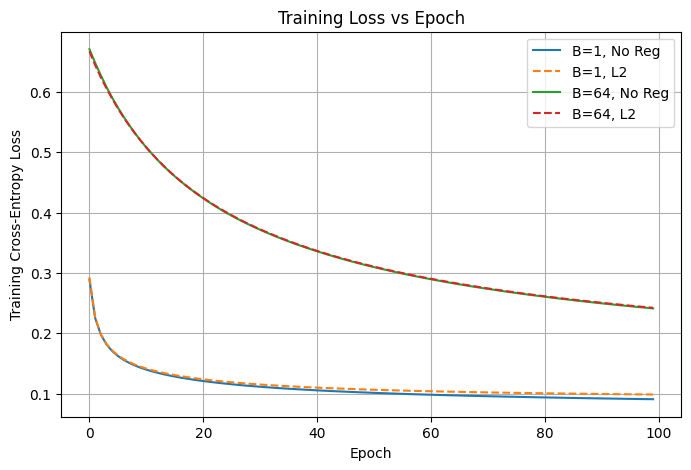

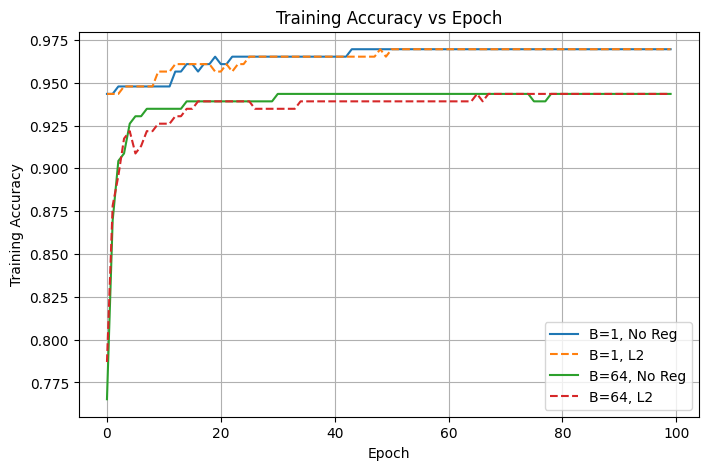

In [ ]:
lr = 1e-2
B_values = [1, 64]

plt.figure(figsize=(8,5))

for B in B_values:
    losses_no_reg = results[(B, lr)]["no_reg"]["loss"]
    losses_l2 = results[(B, lr)]["l2"]["loss"]

    plt.plot(losses_no_reg, label=f"B={B}, No Reg")
    plt.plot(losses_l2, linestyle="--", label=f"B={B}, L2")

plt.xlabel("Epoch")
plt.ylabel("Training Cross-Entropy Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

for B in B_values:
    acc_no_reg = results[(B, lr)]["no_reg"]["acc"]
    acc_l2 = results[(B, lr)]["l2"]["acc"]

    plt.plot(acc_no_reg, label=f"B={B}, No Reg")
    plt.plot(acc_l2, linestyle="--", label=f"B={B}, L2")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

#Hyperparameter Tuning with K-Fold Cross-Validation



In [ ]:
def compute_accuracy(y_true, y_pred):
    """Accuracy: fraction of correct predictions (threshold 0.5)."""
    y_pred_class = (y_pred >= 0.5).astype(float)
    return np.mean(y_pred_class == y_true)

def run_hyperparameter_search_cv(X, y, K=5):
    """
    K-fold CV over hyperparameter grid. Reports mean cross-entropy and mean accuracy
    for each setting.
    """
    learning_rates = [1, 1e-1, 1e-2, 1e-3, 1e-4]
    batch_sizes = [1, 8, 16, 32, 64]
    epochs_list = [50, 100, 150, 200]
    lam = 1e-3  # fixed L2 for tuning

    results = []
    for lr in learning_rates:
        for B in batch_sizes:
            for epochs in epochs_list:
                mean_ce, mean_acc, sem_ce, sem_acc = k_fold_cross_validate(
                    X, y, K=K, lr=lr, batch_size=B, epochs=epochs, lam=lam
                )
                results.append({
                    "lr": lr, "batch_size": B, "epochs": epochs,
                    "mean_cross_entropy": mean_ce, "mean_accuracy": mean_acc,
                    "sem_cross_entropy": sem_ce, "sem_accuracy": sem_acc
                })
                print(f"lr={lr}, B={B}, epochs={epochs} -> mean_CE={mean_ce:.4f}±{sem_ce:.4f}, mean_acc={mean_acc:.4f}±{sem_acc:.4f}")

    return results

def k_fold_cross_validate(X, y, K=5, lr=1e-2, batch_size=16, epochs=100, lam=0.0):
    """
    K-fold cross-validation. For each fold: train on K-1 folds, evaluate on held-out fold.
    Returns (mean_cross_entropy, mean_accuracy) across folds.
    """
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    fold_size = n_samples // K
    fold_ce = []
    fold_acc = []

    for k in range(K):
        val_start = k * fold_size
        val_end = (k + 1) * fold_size if k < K - 1 else n_samples
        val_idx = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])

        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]

        # Standardize using training fold only
        mean = X_train_fold.mean(axis=0)
        std = X_train_fold.std(axis=0)
        std[std == 0] = 1.0
        X_train_fold = (X_train_fold - mean) / std
        X_val_fold = (X_val_fold - mean) / std

        w, b, _, _ = train_logistic_regression(
            X_train_fold, y_train_fold,
            lr=lr, batch_size=batch_size, epochs=epochs, lam=lam
        )

        y_pred_val = forward(X_val_fold, w, b)
        ce = cross_entropy_loss(y_val_fold, y_pred_val)
        acc = compute_accuracy(y_val_fold, y_pred_val)
        fold_ce.append(ce)
        fold_acc.append(acc)

    mean_ce = np.mean(fold_ce)
    mean_acc = np.mean(fold_acc)
    sem_ce = np.std(fold_ce) / np.sqrt(K)  # standard error of the mean
    sem_acc = np.std(fold_acc) / np.sqrt(K)
    return mean_ce, mean_acc, sem_ce, sem_acc

In [ ]:
# Running K-Fold CV
cv_results = run_hyperparameter_search_cv(X_train_unstandardized, y_train, K=5)

lr=1, B=1, epochs=50 -> mean_CE=1.7744±0.1666, mean_acc=0.8478±0.0087
lr=1, B=1, epochs=100 -> mean_CE=1.9183±0.5780, mean_acc=0.8348±0.0346
lr=1, B=1, epochs=150 -> mean_CE=1.7870±0.2042, mean_acc=0.8478±0.0106
lr=1, B=1, epochs=200 -> mean_CE=1.6957±0.1571, mean_acc=0.8739±0.0143
lr=1, B=8, epochs=50 -> mean_CE=0.8090±0.2972, mean_acc=0.8739±0.0333
lr=1, B=8, epochs=100 -> mean_CE=1.0476±0.2232, mean_acc=0.8478±0.0106
lr=1, B=8, epochs=150 -> mean_CE=0.7468±0.2550, mean_acc=0.8739±0.0167
lr=1, B=8, epochs=200 -> mean_CE=0.6930±0.1434, mean_acc=0.8565±0.0132
lr=1, B=16, epochs=50 -> mean_CE=0.5020±0.1317, mean_acc=0.8913±0.0319
lr=1, B=16, epochs=100 -> mean_CE=0.6770±0.2227, mean_acc=0.8826±0.0209
lr=1, B=16, epochs=150 -> mean_CE=0.8218±0.2588, mean_acc=0.8696±0.0307
lr=1, B=16, epochs=200 -> mean_CE=0.7513±0.2174, mean_acc=0.8739±0.0073
lr=1, B=32, epochs=50 -> mean_CE=0.6707±0.1817, mean_acc=0.8913±0.0254
lr=1, B=32, epochs=100 -> mean_CE=0.6039±0.1576, mean_acc=0.8783±0.0132
lr=1


Full table saved to cv_hyperparameter_results.csv


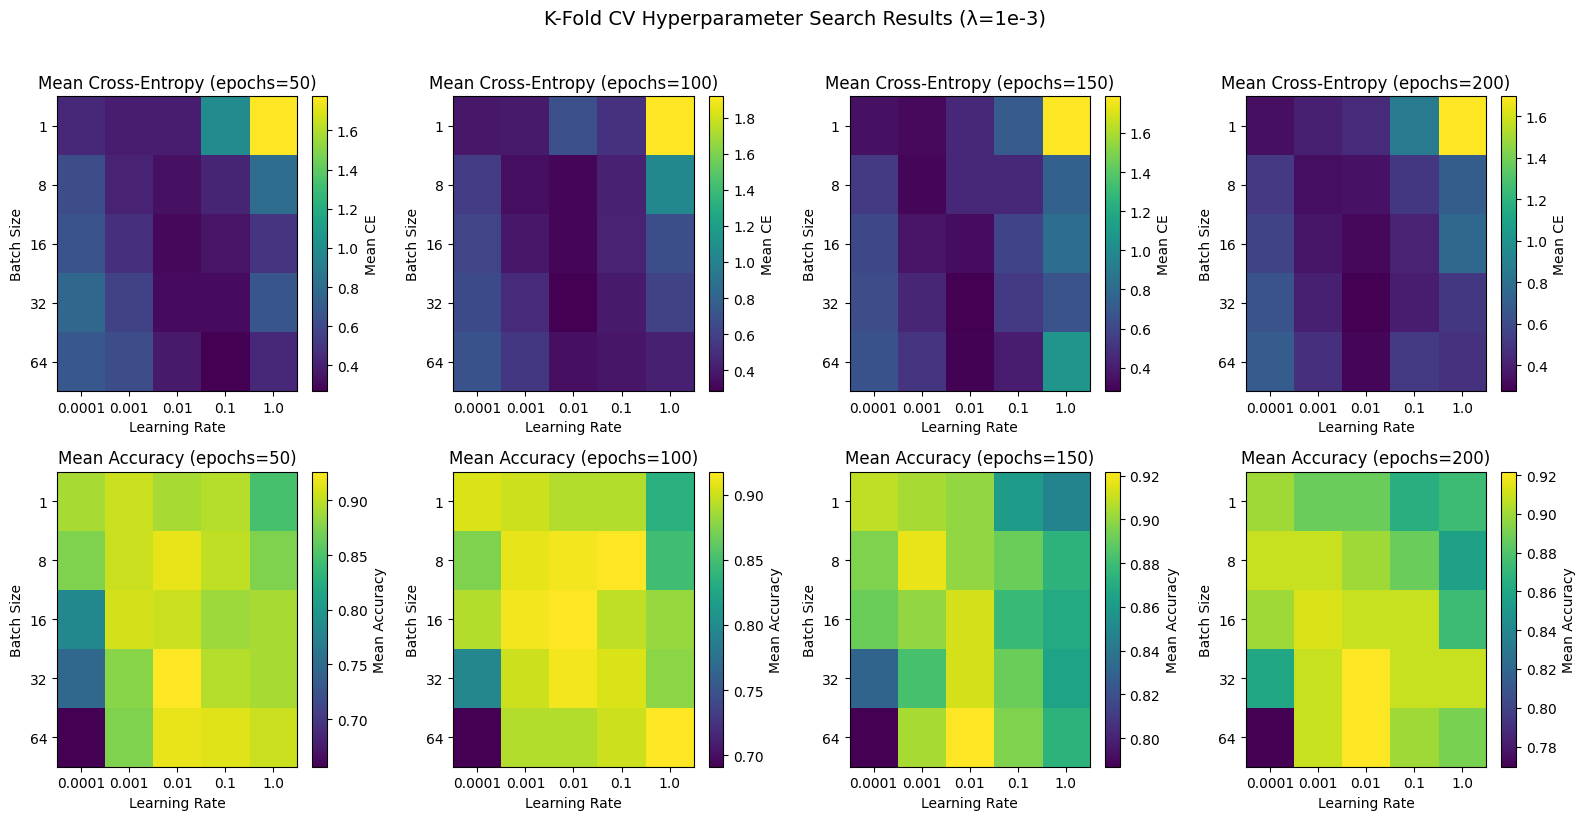

Summary figure saved to cv_hyperparameter_summary.png


In [ ]:
# CV plots
def plot_cv_results_summary(cv_results):
    """Create a table (CSV) and figure summarizing CV hyperparameter search results."""
    df = pd.DataFrame(cv_results)
    df = df[["lr", "batch_size", "epochs", "mean_cross_entropy", "mean_accuracy"]]
    df.columns = ["Learning Rate", "Batch Size", "Epochs", "Mean CE", "Mean Accuracy"]
    df.to_csv("cv_hyperparameter_results.csv", index=False)
    print("\nFull table saved to cv_hyperparameter_results.csv")

    learning_rates = sorted(df["Learning Rate"].unique())
    batch_sizes = sorted(df["Batch Size"].unique())
    epochs_list = sorted(df["Epochs"].unique())

    fig, axes = plt.subplots(2, len(epochs_list), figsize=(4 * len(epochs_list), 8))

    for col, epochs in enumerate(epochs_list):
        subset = df[df["Epochs"] == epochs]
        ce_grid = subset.pivot(index="Batch Size", columns="Learning Rate", values="Mean CE")
        acc_grid = subset.pivot(index="Batch Size", columns="Learning Rate", values="Mean Accuracy")
        ce_grid = ce_grid.reindex(index=batch_sizes, columns=learning_rates)
        acc_grid = acc_grid.reindex(index=batch_sizes, columns=learning_rates)

        im0 = axes[0, col].imshow(ce_grid.values, aspect="auto", cmap="viridis")
        axes[0, col].set_xticks(range(len(learning_rates)))
        axes[0, col].set_xticklabels(learning_rates)
        axes[0, col].set_yticks(range(len(batch_sizes)))
        axes[0, col].set_yticklabels(batch_sizes)
        axes[0, col].set_xlabel("Learning Rate")
        axes[0, col].set_ylabel("Batch Size")
        axes[0, col].set_title(f"Mean Cross-Entropy (epochs={epochs})")
        plt.colorbar(im0, ax=axes[0, col], label="Mean CE")

        im1 = axes[1, col].imshow(acc_grid.values, aspect="auto", cmap="viridis")
        axes[1, col].set_xticks(range(len(learning_rates)))
        axes[1, col].set_xticklabels(learning_rates)
        axes[1, col].set_yticks(range(len(batch_sizes)))
        axes[1, col].set_yticklabels(batch_sizes)
        axes[1, col].set_xlabel("Learning Rate")
        axes[1, col].set_ylabel("Batch Size")
        axes[1, col].set_title(f"Mean Accuracy (epochs={epochs})")
        plt.colorbar(im1, ax=axes[1, col], label="Mean Accuracy")

    fig.suptitle("K-Fold CV Hyperparameter Search Results (λ=1e-3)", fontsize=14, y=1.02)
    plt.tight_layout()
    # plt.savefig("cv_hyperparameter_summary.png", bbox_inches="tight")
    plt.show()
    print("Summary figure saved to cv_hyperparameter_summary.png")

plot_cv_results_summary(cv_results)

In [ ]:
# Hyperparameter selection
def select_best_config_one_se(cv_results):
    """
    One-standard-error rule: pick the simplest model within 1 SE of the best score.
    Simplicity: fewer epochs first, then larger batch size. Based on higher accuracy is better.
    """
    best_val = max(r["mean_accuracy"] for r in cv_results)
    best_config = max(cv_results, key=lambda r: r["mean_accuracy"])
    best_sem = best_config["sem_accuracy"]
    threshold = best_val - best_sem
    within = [r for r in cv_results if r["mean_accuracy"] >= threshold]
    # Sort by simplicity: fewer epochs, then larger batch size
    within.sort(key=lambda r: (r["epochs"], -r["batch_size"]))
    return within[0], best_val, best_sem, threshold

# One-SE rule: pick simplest model within 1 SE of best
best_config, best_val, best_sem, threshold = select_best_config_one_se(cv_results)
for key, value in best_config.items():
    print(f"  {key}: {value}")

print(f"\nBest validation accuracy (all configurations): {best_val:.4f}")
print(f"Standard error of the mean for best accuracy: {best_sem:.4f}")
print(f"Threshold (best_val - best_sem) for 1-SE rule: {threshold:.4f}")


  lr: 0.01
  batch_size: 64
  epochs: 50
  mean_cross_entropy: 0.3766249984859795
  mean_accuracy: 0.9173913043478261
  sem_cross_entropy: 0.006509916054129448
  sem_accuracy: 0.009525609695742033

Best validation accuracy (all configurations): 0.9261
Standard error of the mean for best accuracy: 0.0099
Threshold (best_val - best_sem) for 1-SE rule: 0.9162


#Bias–Variance Trade-Off via λ Sweep (With K-Fold CV)


In [ ]:
def standardize_fit_transform(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std = np.where(std == 0, 1.0, std)
    X_std = (X - mean) / std
    return X_std, mean, std

def standardize_transform(X, mean, std):
    return (X - mean) / std

def compute_accuracy(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return np.mean(y_pred == y_true)

def make_kfold_indices(n_samples, k, rng_obj):
    indices = rng_obj.permutation(n_samples)
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[:n_samples % k] += 1

    folds = []
    start = 0
    for fold_size in fold_sizes:
        stop = start + fold_size
        val_idx = indices[start:stop]
        train_idx = np.concatenate((indices[:start], indices[stop:]))
        folds.append((train_idx, val_idx))
        start = stop
    return folds

def run_lambda_sweep_cv(
    X_train_raw,
    y_train_raw,
    lambdas,
    k=5,
    lr=0.1,
    batch_size=16,
    epochs=200
):
    folds = make_kfold_indices(X_train_raw.shape[0], k, rng)
    results_rows = []

    for lam in lambdas:
        fold_train_ce = []
        fold_val_ce = []
        fold_train_acc = []
        fold_val_acc = []

        for train_idx, val_idx in folds:
            X_fold_train = X_train_raw[train_idx]
            y_fold_train = y_train_raw[train_idx]
            X_fold_val = X_train_raw[val_idx]
            y_fold_val = y_train_raw[val_idx]

            X_fold_train_std, fold_mean, fold_std = standardize_fit_transform(X_fold_train)
            X_fold_val_std = standardize_transform(X_fold_val, fold_mean, fold_std)

            w, b, _, _ = train_logistic_regression(
                X_fold_train_std,
                y_fold_train,
                lr=lr,
                batch_size=batch_size,
                epochs=epochs,
                lam=lam
            )

            y_train_prob = forward(X_fold_train_std, w, b)
            y_val_prob = forward(X_fold_val_std, w, b)

            fold_train_ce.append(cross_entropy_loss(y_fold_train, y_train_prob))
            fold_val_ce.append(cross_entropy_loss(y_fold_val, y_val_prob))
            fold_train_acc.append(compute_accuracy(y_fold_train, y_train_prob))
            fold_val_acc.append(compute_accuracy(y_fold_val, y_val_prob))

        results_rows.append({
            "lambda": lam,
            "train_ce_mean": np.mean(fold_train_ce),
            "val_ce_mean": np.mean(fold_val_ce),
            "train_acc_mean": np.mean(fold_train_acc),
            "val_acc_mean": np.mean(fold_val_acc),
            "train_ce_std": np.std(fold_train_ce),
            "val_ce_std": np.std(fold_val_ce),
            "train_acc_std": np.std(fold_train_acc),
            "val_acc_std": np.std(fold_val_acc),
        })

    return pd.DataFrame(results_rows)

In [ ]:
# Task 3 implementation (fixed hyperparameters + lambda sweep with K-fold CV)
task3_lr = 0.1
task3_batch_size = 16
task3_epochs = 200
task3_k = 5
task3_lambdas = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]

task3_cv_df = run_lambda_sweep_cv(
    X_train_raw=X_train,
    y_train_raw=y_train,
    lambdas=task3_lambdas,
    k=task3_k,
    lr=task3_lr,
    batch_size=task3_batch_size,
    epochs=task3_epochs
)

print("\nTask 3 CV results (lambda sweep):")
print(task3_cv_df.to_string(index=False))

/tmp/ipython-input-288/1247648305.py:4: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))



Task 3 CV results (lambda sweep):
  lambda  train_ce_mean  val_ce_mean  train_acc_mean  val_acc_mean  train_ce_std  val_ce_std  train_acc_std  val_acc_std
0.000000       0.073167     0.527077        0.981522      0.895652      0.013381    0.288828       0.005542     0.031950
0.000001       0.073146     0.520718        0.980435      0.895652      0.013384    0.287145       0.005542     0.031950
0.000010       0.073191     0.526344        0.982609      0.895652      0.013284    0.288143       0.004067     0.031950
0.000100       0.074023     0.516717        0.981522      0.895652      0.013307    0.283267       0.005542     0.031950
0.001000       0.082019     0.446532        0.978261      0.891304      0.012731    0.231056       0.007686     0.027498
0.010000       0.132791     0.295849        0.966304      0.900000      0.009965    0.091944       0.009350     0.022170
0.100000       0.259931     0.550123        0.944565      0.891304      0.006744    0.488498       0.012104     0.0363

In [ ]:
# Choose best lambda: min validation CE, tie-break with max val acc, then larger lambda
task3_best_row = task3_cv_df.sort_values(
    by=["val_ce_mean", "val_acc_mean", "lambda"],
    ascending=[True, False, False]
).iloc[0]
task3_best_lambda = float(task3_best_row["lambda"])

print(
    f"\nSelected lambda from CV: {task3_best_lambda} "
    f"(val CE={task3_best_row['val_ce_mean']:.4f}, "
    f"val acc={task3_best_row['val_acc_mean']:.4f})"
)


Selected lambda from CV: 0.01 (val CE=0.2958, val acc=0.9000)


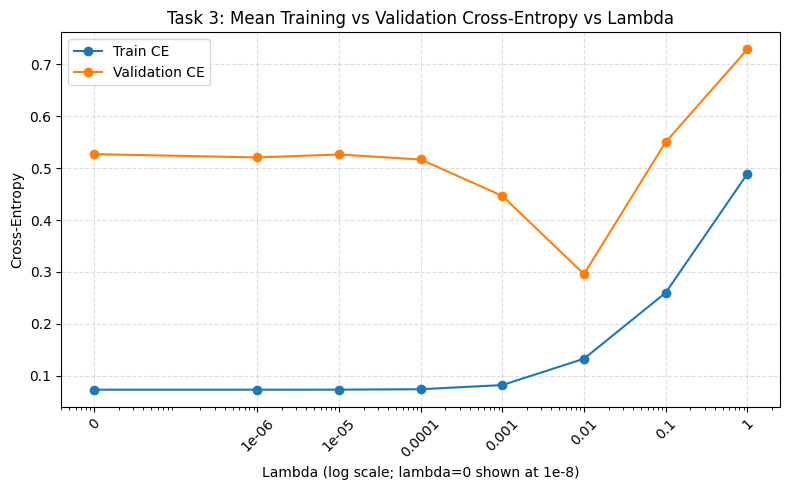

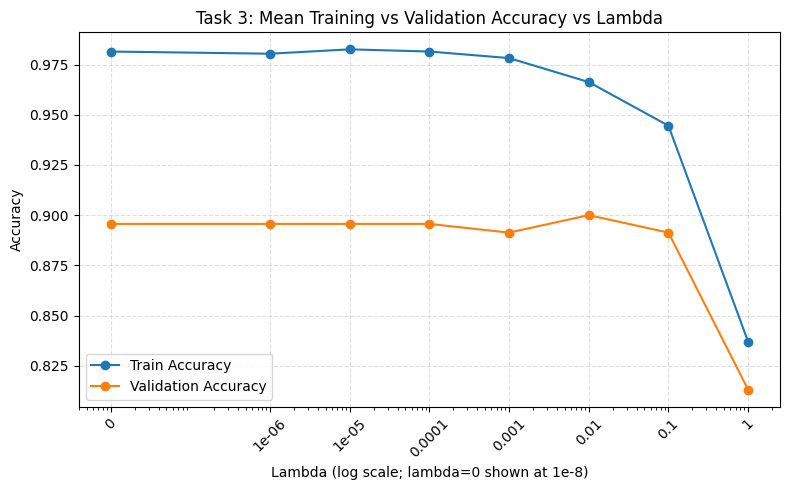


Task 3 curve-based explanation:
1) Small lambda effect: with very weak regularization (near lambda=0), training CE is usually low, but validation CE can be higher due to overfitting (higher variance).
2) Large lambda effect: with strong regularization (e.g., lambda near 1), weights are heavily shrunk, which increases training CE and can reduce validation performance (underfitting, higher bias).
3) U-shape intuition: validation CE often improves from tiny lambda values to an intermediate region (best here around lambda=0.01), then worsens again as lambda becomes too large.
Observed endpoints used for interpretation: smallest lambda=0, largest lambda=1.


In [ ]:
# Plotting prep: lambda=0 cannot be shown directly on a log axis
plot_lambdas = np.array([1e-8 if lam == 0 else lam for lam in task3_cv_df["lambda"].to_numpy()])
plot_labels = [f"{lam:g}" for lam in task3_cv_df["lambda"].to_list()]

plt.figure(figsize=(8, 5))
plt.plot(plot_lambdas, task3_cv_df["train_ce_mean"], marker="o", label="Train CE")
plt.plot(plot_lambdas, task3_cv_df["val_ce_mean"], marker="o", label="Validation CE")
plt.xscale("log")
plt.xticks(plot_lambdas, plot_labels, rotation=45)
plt.xlabel("Lambda (log scale; lambda=0 shown at 1e-8)")
plt.ylabel("Cross-Entropy")
plt.title("Task 3: Mean Training vs Validation Cross-Entropy vs Lambda")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(plot_lambdas, task3_cv_df["train_acc_mean"], marker="o", label="Train Accuracy")
plt.plot(plot_lambdas, task3_cv_df["val_acc_mean"], marker="o", label="Validation Accuracy")
plt.xscale("log")
plt.xticks(plot_lambdas, plot_labels, rotation=45)
plt.xlabel("Lambda (log scale; lambda=0 shown at 1e-8)")
plt.ylabel("Accuracy")
plt.title("Task 3: Mean Training vs Validation Accuracy vs Lambda")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

task3_val_min_idx = int(np.argmin(task3_cv_df["val_ce_mean"].to_numpy()))
task3_val_min_lambda = float(task3_cv_df.iloc[task3_val_min_idx]["lambda"])
task3_small_lambda = float(task3_cv_df.iloc[0]["lambda"])
task3_large_lambda = float(task3_cv_df.iloc[-1]["lambda"])

print("\nTask 3 curve-based explanation:")
print(
    "1) Small lambda effect: with very weak regularization (near lambda=0), "
    "training CE is usually low, but validation CE can be higher due to overfitting "
    "(higher variance)."
)
print(
    "2) Large lambda effect: with strong regularization (e.g., lambda near 1), "
    "weights are heavily shrunk, which increases training CE and can reduce validation "
    "performance (underfitting, higher bias)."
)
print(
    "3) U-shape intuition: validation CE often improves from tiny lambda values to an "
    f"intermediate region (best here around lambda={task3_val_min_lambda:g}), then worsens "
    "again as lambda becomes too large."
)
print(
    f"Observed endpoints used for interpretation: smallest lambda={task3_small_lambda:g}, "
    f"largest lambda={task3_large_lambda:g}."
)

In [ ]:
# Final test evaluation with selected lambda
# Fit scaler on full training split only, then transform train/test (no leakage)
X_train_std_full, train_mean_full, train_std_full = standardize_fit_transform(X_train)
X_test_std = standardize_transform(X_test, train_mean_full, train_std_full)

task3_final_w, task3_final_b, _, _ = train_logistic_regression(
    X_train_std_full,
    y_train,
    lr=task3_lr,
    batch_size=task3_batch_size,
    epochs=task3_epochs,
    lam=task3_best_lambda
)

task3_test_prob = forward(X_test_std, task3_final_w, task3_final_b)
task3_test_ce = cross_entropy_loss(y_test, task3_test_prob)
task3_test_acc = compute_accuracy(y_test, task3_test_prob)

print("\nTask 3 Final Test Evaluation (held-out test set):")
print(f"Best lambda (from CV): {task3_best_lambda:g}")
print(f"Test cross-entropy: {task3_test_ce:.4f}")
print(f"Test accuracy: {task3_test_acc:.4f}")


Task 3 Final Test Evaluation (held-out test set):
Best lambda (from CV): 0.01
Test cross-entropy: 0.3143
Test accuracy: 0.8987


#L1-Regularized Logistic Regression and the Regularization Path (Using scikit-learn)


In [ ]:
from sklearn.linear_model import LogisticRegression

Cs = np.logspace(-4, 4, 30)

coefs = []
nonzero_counts = []

for C in Cs:
    clf = LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=5000,
        C=C,
        random_state=0
    )
    clf.fit(X_train, y_train)

    w = clf.coef_.ravel()
    coefs.append(w)
    nonzero_counts.append(np.sum(np.abs(w) > 1e-6))

coefs = np.array(coefs)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

## **What the regularization path represents**

The regularization path shows how the learned model coefficients change as the strength of L1 regularization varies. In L1-regularized logistic regression, strong regularization (small 𝐶) forces many coefficients to be exactly zero, producing a sparse and interpretable model. As regularization weakens (larger 𝐶), more features enter the model and coefficients grow in magnitude.

The path therefore illustrates the trade-off between sparsity (interpretability) and model flexibility.

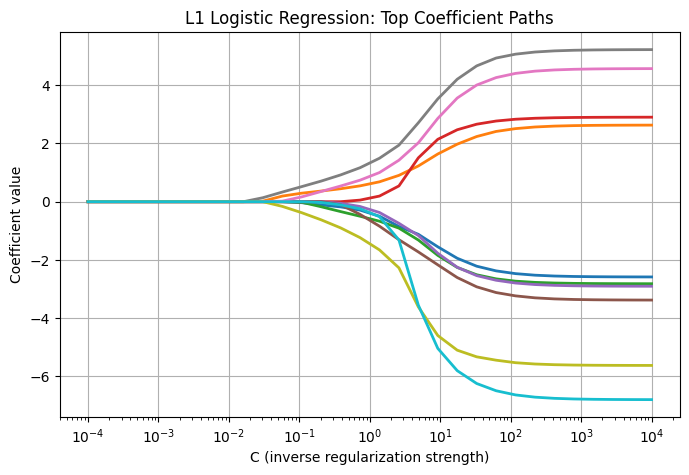

In [ ]:
k = 10  # number of features to show
max_abs = np.max(np.abs(coefs), axis=0)
top_idx = np.argsort(max_abs)[-k:]

plt.figure(figsize=(8, 5))

for j in top_idx:
    plt.plot(Cs, coefs[:, j], linewidth=2)

plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Coefficient value")
plt.title("L1 Logistic Regression: Top Coefficient Paths")
plt.grid(True)
plt.show()

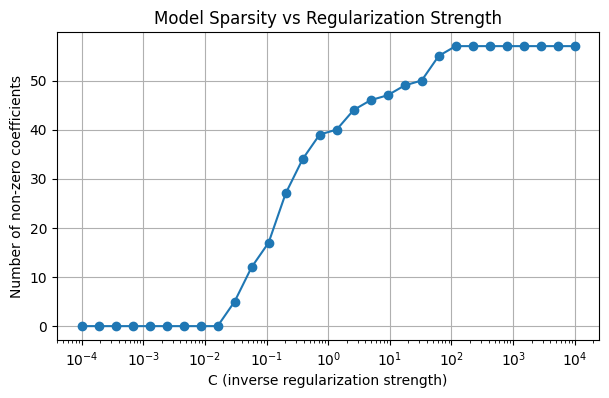

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(Cs, nonzero_counts, marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Number of non-zero coefficients")
plt.title("Model Sparsity vs Regularization Strength")
plt.grid(True)
plt.show()

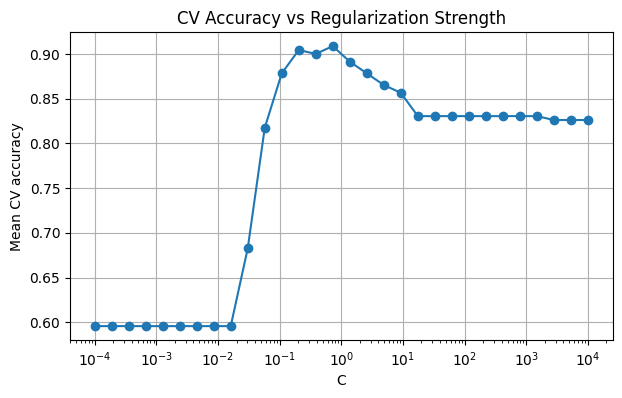

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

clf_cv = LogisticRegressionCV(
    Cs=Cs,
    penalty="l1",
    solver="saga",
    cv=5,
    scoring="accuracy",
    max_iter=5000
)
clf_cv.fit(X_train, y_train)

mean_scores = clf_cv.scores_[1].mean(axis=0)

plt.figure(figsize=(7, 4))
plt.plot(Cs, mean_scores, marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean CV accuracy")
plt.title("CV Accuracy vs Regularization Strength")
plt.grid(True)
plt.show()

## **Discussion**

**How sparsity changes**

With strong regularization (small 𝐶), most coefficients are exactly zero, resulting in a highly sparse model. As 𝐶 increases, more coefficients become non-zero, increasing model complexity.

**Most important features**

Features that become non-zero earliest and grow consistently across the path appear to be the most important, as they are selected even under strong regularization.

**Interpretability vs performance trade-off**

Sparse models at small 𝐶 are easier to interpret but may underfit. As regularization weakens, performance typically improves up to a point, after which additional features add little predictive value while reducing interpretability.